# Testing the Rule

<!-- SUMMARY: Pluri-Gaussian simulations performed in 2D -->

<!-- CATEGORY: Methodology -->

In [1]:
import pandas as pd
import gstlearn as gl
import gstlearn.plot as gp
import gstlearn.document as gdoc
import random as rnd

gdoc.setNoScroll()

<IPython.core.display.Javascript object>

In [2]:
ndim = 2
gl.defineDefaultSpace(gl.ESpaceType.RN, ndim)
gl.set_test_discrete(False)

Creating the Rule and defining specifically the name of the second facies (its rank is entered as 1 as the argument is 0-based) and the assigned value for the third facies. The other values are kept unchanged, as set by default.

In [3]:
rule = gl.Rule.createFromNames(["S", "T", "F1", "F2", "F3"])
rule.setFaciesName(1, "MyFacies")
rule.setFaciesValue(2, 6)

We can check the additional characteristics attached to the Rule.

In [4]:
rule.display()


Lithotype Rule
- Number of nodes               = 5
- Number of facies              = 3
- Number of thresholds along G1 = 1
- Number of thresholds along G2 = 1

Node Characteristics
--------------------
Node F1 - Facies 1
Node F2 - Facies 2
Node F3 - Facies 3

Facies Characteristics
----------------------
Facies 1 - Name = F1 - Color = #1f77b4ff - Assigned Value = 0
Facies 2 - Name = MyFacies - Color = #ff7f0eff - Assigned Value = 1
Facies 3 - Name = F3 - Color = #2ca02cff - Assigned Value = 6


These characteristics are used for the representation of the Rule itself.

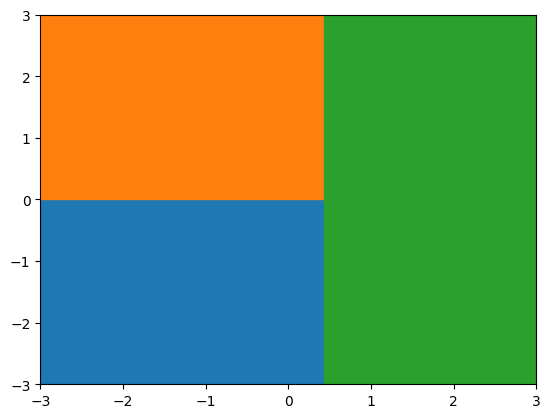

In [5]:
res = gp.plot(rule)

We perform a non-conditional simulation using PGS method.

In [6]:
grid = gl.DbGrid.create(nx=[110, 110])
model1 = gl.Model.createFromParam(gl.ECov.CUBIC, ranges=[20, 30])
model2 = gl.Model.createFromParam(gl.ECov.EXPONENTIAL, 30, 1.0, 1.0)

nbsimu = 1
ruleprop = gl.RuleProp.createFromRule(rule)
err = gl.simpgs(dbin=None, dbout=grid, ruleprop=ruleprop, model1=model1, model2=model2)

Facies read
[0 3186 5232 3682 0 0 0 0 0 0]
[3186 5232 0 0 0 0 3682 0 0 0]
Facies written


The following statistics demonstrate that the "Facies" variable (produced by PGS) has values coming from the assigned values per facies, as defined in Rule.

In [7]:
grid.getStatsAsTable()

            Number     Minimum     Maximum        Mean    St. Dev.    Variance
  rank   12100.000       1.000   12100.000    6050.500    3492.969 12200833.250
    x1   12100.000       0.000     109.000      54.500      31.753    1008.250
    x2   12100.000       0.000     109.000      54.500      31.753    1008.250
Facies   12100.000       0.000       6.000       2.258       2.508       6.288

Representing the grid of facies with the colors as defined in the Rule. The Legend is adapted.

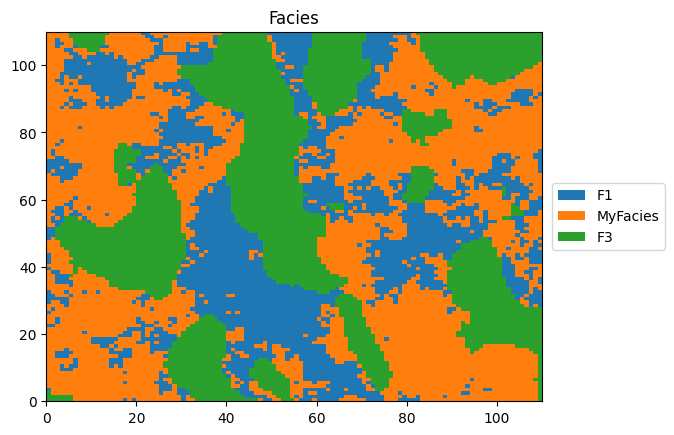

In [8]:
ax = gp.plot(grid, rule=rule, flagLegend=True)

We sample the previous simulated grid in order to generate a Data base constituted of isolated points (named "data")

In [9]:
ndat = 20
randomlist = rnd.sample(range(0, grid.getNSample()), ndat)
data = gl.Db.createReduce(grid, ranks=randomlist)

The graphic representation of symbol (using the "nameColor" argument) is adapted to the representation of categorial information.

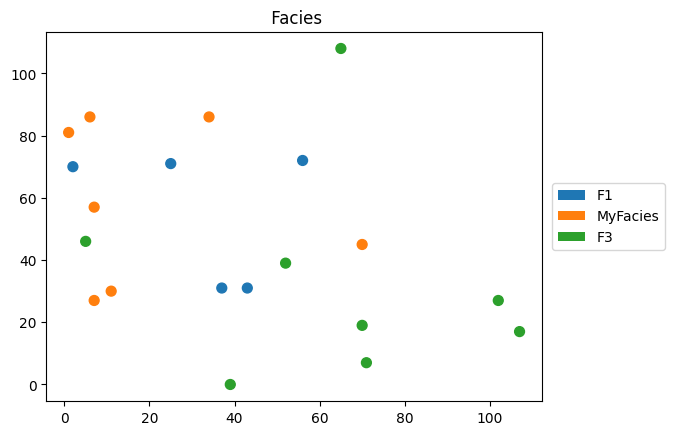

In [10]:
ax = gp.plot(data, nameColor="Facies", rule=rule, s=50, flagLegendColor=True)

The following plot demonstrates the possibility of overlaying the two previous graphic representations. Note that the symbols are represented with an additional colored edge (white).

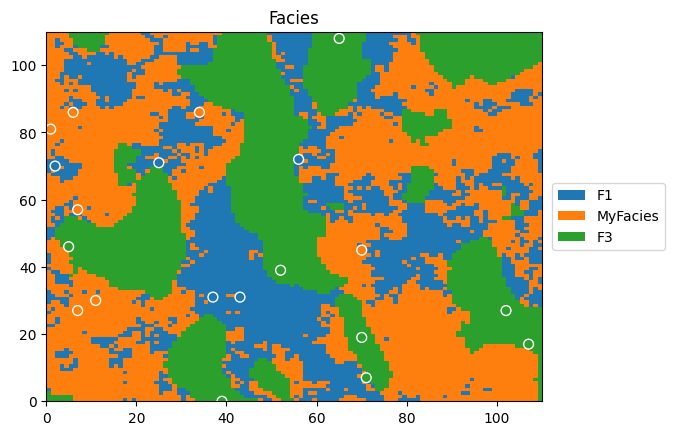

In [11]:
fig, ax = gp.init()
ax = gp.plot(grid, rule=rule, flagLegend=True)
ax = gp.plot(
    data, nameColor="Facies", rule=rule, s=50, flagLegendColor=True, edgecolors="white"
)
gp.close()